In [32]:
# Standard operational package imports.
import numpy as np
import pandas as pd

# Important imports for preprocessing, modeling, and evaluation.
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import pickle as pkl
 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
# Visualization package imports.
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_original = pd.read_csv("00-dataset/Invistico_Airline.csv") 

In [5]:
df_original.head(n = 10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


### Data exploration, data cleaning, and model preparation

In [6]:
df_original.dtypes

satisfaction                          object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
dtype: obj

In [7]:
df_original["Class"].unique()

array(['Eco', 'Business', 'Eco Plus'], dtype=object)

In [8]:
df_original['satisfaction'].value_counts(dropna = False)

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [9]:

df_original.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [10]:
df_subset = df_original.dropna(axis=0).reset_index(drop = True)

#### Encode the data

In [11]:
df_subset['satisfaction'] = df_subset['satisfaction'].map({"satisfied": 1, "dissatisfied": 0})


In [12]:
df_subset.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,1,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,1,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,1,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,1,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,1,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


## Logistic regression

#### Convert categorical columns into numeric

In [13]:
df_subset = df_subset.astype({"Inflight entertainment": float})

In [14]:
X = df_subset[["Inflight entertainment"]]
y = df_subset["satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(X,y ,test_size=0.3,random_state=42)

In [15]:
clf = LogisticRegression().fit(X_train,y_train)

In [16]:
print(f"the intercept {clf.intercept_}")
print(f"the coef {clf.coef_}")

the intercept [-3.19359054]
the coef [[0.99752883]]


<Axes: xlabel='Inflight entertainment', ylabel='satisfaction'>

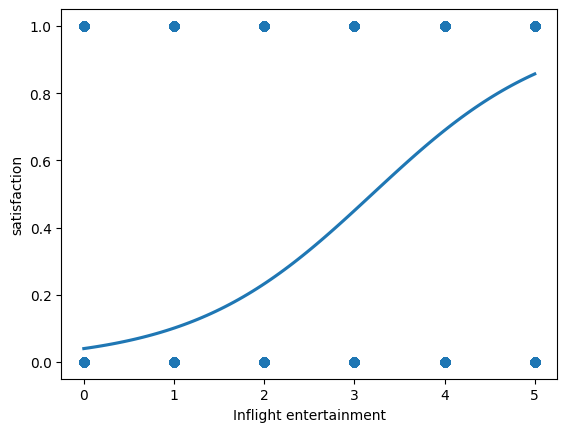

In [17]:
sns.regplot(x="Inflight entertainment", y="satisfaction", data=df_subset, logistic=True, ci=None)

In [18]:
df_subset.shape

(129487, 22)

In [19]:
y_pred = clf.predict(X_test)

In [20]:
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, y_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, y_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, y_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, y_pred))

Accuracy: 0.801529
Precision: 0.816142
Recall: 0.821530
F1 Score: 0.818827


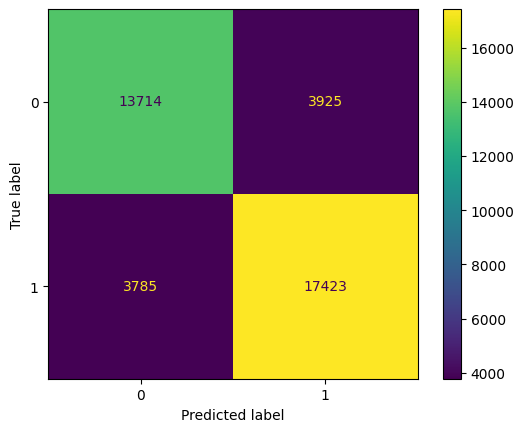

In [21]:
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
disp.plot()

## decision tree


In [22]:
df_subset['Class'] = df_subset['Class'].map({"Business": 3, "Eco Plus": 2, "Eco": 1})

In [23]:
df_subset = pd.get_dummies(df_subset, drop_first = True)

In [24]:
df_subset.dtypes

satisfaction                           int64
Age                                    int64
Class                                  int64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment               float64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_disloyal Customer         bool
Type of Travel_Personal Travel          bool
dtype: obj

In [25]:
y_dtree = df_subset["satisfaction"]

X_dtree = df_subset.copy()
X_dtree = X_dtree.drop("satisfaction", axis = 1)

X_train_dtree, X_test_dtree, y_train_dtree, y_test_dtree = train_test_split(X_dtree, y_dtree, test_size=0.25, random_state=0)

In [26]:
decision_tree = DecisionTreeClassifier(random_state=0)

decision_tree.fit(X_train_dtree, y_train_dtree)

dt_pred_dtree = decision_tree.predict(X_test_dtree)

In [27]:
print("Decision Tree")
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test_dtree, dt_pred_dtree))
print("Precision:", "%.6f" % metrics.precision_score(y_test_dtree, dt_pred_dtree))
print("Recall:", "%.6f" % metrics.recall_score(y_test_dtree, dt_pred_dtree))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test_dtree, dt_pred_dtree))

Decision Tree
Accuracy: 0.935438
Precision: 0.942859
Recall: 0.939030
F1 Score: 0.940940


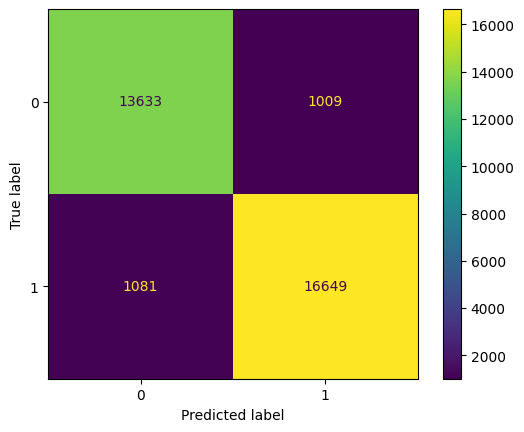

In [28]:
cm = metrics.confusion_matrix(y_test_dtree, dt_pred_dtree, labels = decision_tree.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = decision_tree.classes_)
disp.plot()

[Text(0.5, 0.875, 'Inflight entertainment <= 3.5\ngini = 0.496\nsamples = 97115\nvalue = [43963, 53152]'),
 Text(0.25, 0.625, 'Seat comfort <= 3.5\ngini = 0.339\nsamples = 43502\nvalue = [34098, 9404]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Seat comfort <= 0.5\ngini = 0.247\nsamples = 38022\nvalue = [32531.0, 5491.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Seat comfort <= 4.5\ngini = 0.408\nsamples = 5480\nvalue = [1567.0, 3913.0]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Ease of Online booking <= 3.5\ngini = 0.3\nsamples = 53613\nvalue = [9865, 43748]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Inflight entertainment <= 4.5\ngini = 0.485\nsamples = 14645\nvalue = [6063, 8582]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Customer Type_disloyal Customer <= 0.5\ngini = 0.176\nsamples = 38

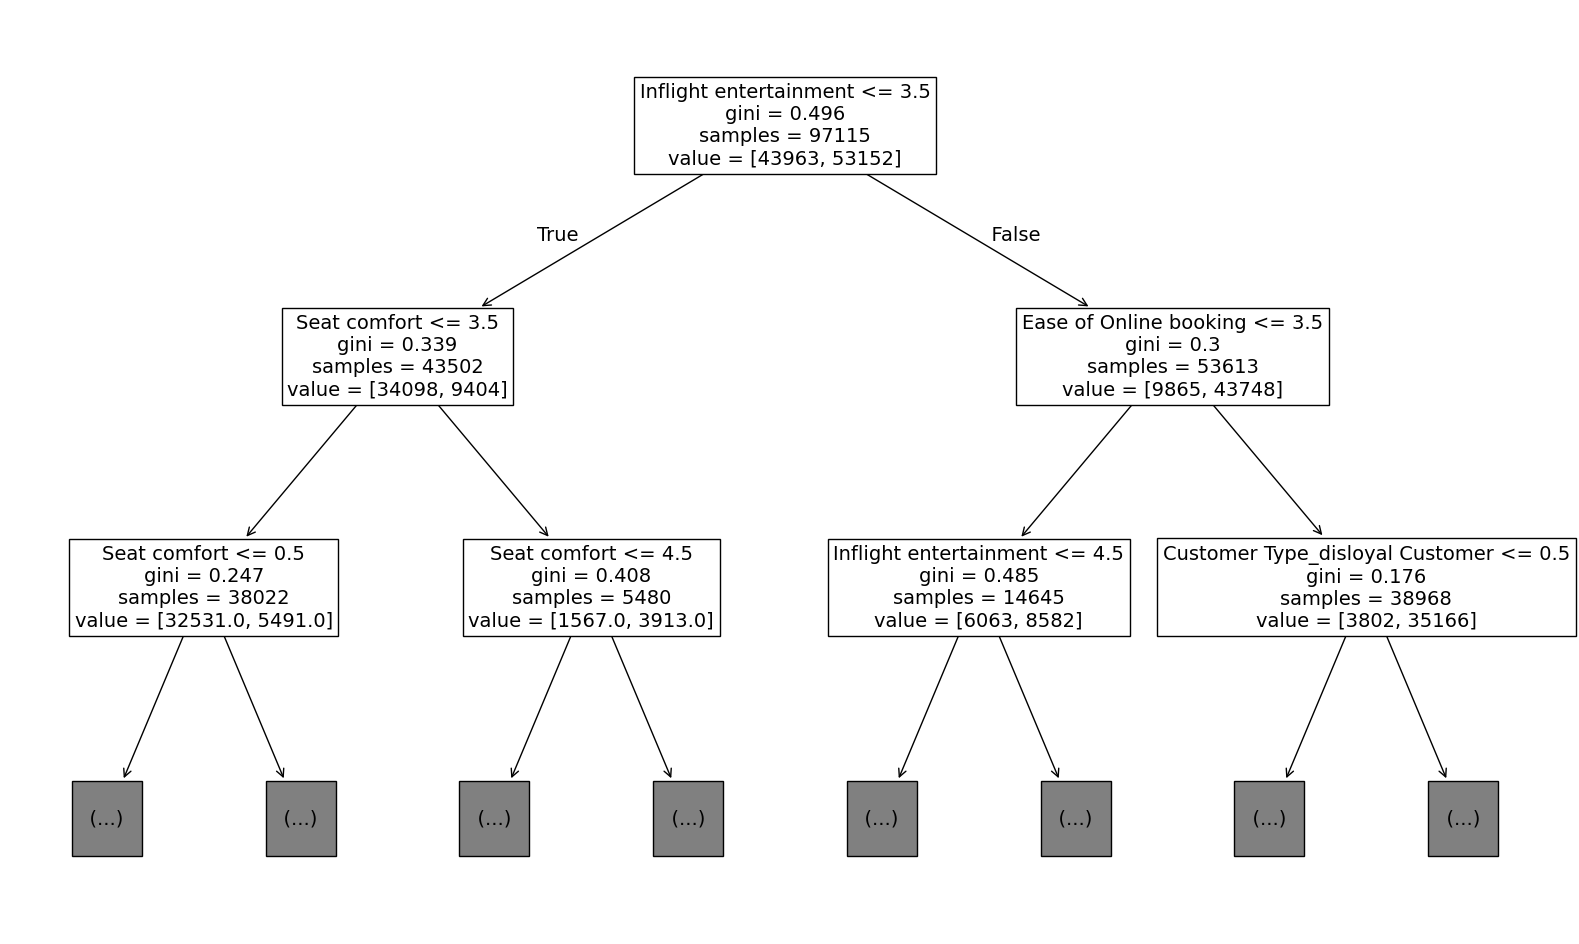

In [29]:
plt.figure(figsize=(20,12))
plot_tree(decision_tree, max_depth=2, fontsize=14, feature_names=X_dtree.columns)

#### Hyperparameter tuning

In [30]:
tree_para = {'max_depth':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50],
             'min_samples_leaf': [2,3,4,5,6,7,8,9, 10, 15, 20, 50]}

scoring = scoring = {
    'f1': 'f1',
    'recall': 'recall',
    'accuracy': 'accuracy',
    'precision': 'precision'
}

In [31]:
tuned_decision_tree = DecisionTreeClassifier(random_state=0)

clf = GridSearchCV(tuned_decision_tree,
                   tree_para,
                   scoring=scoring,
                   cv=5,
                   refit="f1")
clf.fit(X_train_dtree, y_train_dtree)

KeyboardInterrupt: 

In [ ]:
clf.best_estimator_

DecisionTreeClassifier(max_depth=15, min_samples_leaf=3, random_state=0)

In [ ]:
print("Best Avg. Validation Score: ", "%.4f" % clf.best_score_)

Best Avg. Validation Score:  0.9439


In [ ]:
results = pd.DataFrame(columns=['Model', 'F1', 'Recall', 'Precision', 'Accuracy'])

def make_results(model_name, model_object):
    
    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score).
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row.
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

 
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]
                         }
                        )

    return table

result_table = make_results("Tuned Decision Tree", clf)

result_table

,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.943882,0.932872,0.955165,0.939288


## Random forest 

In [33]:
air_data_subset = df_original.dropna(axis=0)

In [34]:
air_data_subset_dummies = pd.get_dummies(air_data_subset, 
                                         columns=['Customer Type','Type of Travel','Class'])

In [35]:

air_data_subset_dummies.head(10)

,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,satisfied,65,265,0,0,0,2,2,4,2,...,2,0,0.0,True,False,False,True,False,True,False
1,satisfied,47,2464,0,0,0,3,0,2,2,...,2,310,305.0,True,False,False,True,True,False,False
2,satisfied,15,2138,0,0,0,3,2,0,2,...,2,0,0.0,True,False,False,True,False,True,False
3,satisfied,60,623,0,0,0,3,3,4,3,...,3,0,0.0,True,False,False,True,False,True,False
4,satisfied,70,354,0,0,0,3,4,3,4,...,5,0,0.0,True,False,False,True,False,True,False
5,satisfied,30,1894,0,0,0,3,2,0,2,...,2,0,0.0,True,False,False,True,False,True,False
6,satisfied,66,227,0,0,0,3,2,5,5,...,3,17,15.0,True,False,False,True,False,True,False
7,satisfied,10,1812,0,0,0,3,2,0,2,...,2,0,0.0,True,False,False,True,False,True,False
8,satisfied,56,73,0,0,0,3,5,3,5,...,4,0,0.0,True,False,False,True,True,False,False
9,satisfied,22,1556,0,0,0,3,2,0,2,...,2,30,26.0,True,False,False,True,False,True,False


In [36]:
air_data_subset_dummies.dtypes

satisfaction                          object
Age                                    int64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_Loyal Customer            bool
Customer Type_disloyal Customer         bool
Type of Travel_Business travel          bool
Type of Tr

In [39]:
y_rforest = air_data_subset_dummies["satisfaction"]
X_rforest = air_data_subset_dummies.drop("satisfaction", axis=1)

In [40]:
X_train_rforest, X_test_rforest, y_train_rforest, y_test_rforest = train_test_split(X_rforest, y_rforest, test_size = 0.25, random_state = 0)
X_tr_rforest, X_val_rforest, y_tr_rforest, y_val_rforest = train_test_split(X_train_rforest, y_train_rforest, test_size = 0.25, random_state = 0)


In [41]:
cv_params = {'n_estimators' : [50,100], 
              'max_depth' : [10,50],        
              'min_samples_leaf' : [0.5,1], 
              'min_samples_split' : [0.001, 0.01],
              'max_features' : ["sqrt"], 
              'max_samples' : [.5,.9]}

In [42]:
split_index = [0 if x in X_val_rforest.index else -1 for x in X_train_rforest.index]
custom_split = PredefinedSplit(split_index)

In [43]:
rf = RandomForestClassifier(random_state=0)

In [49]:
rf_val_rforest = GridSearchCV(rf, cv_params, cv=custom_split, refit='f1', n_jobs = -1, verbose = 1)

In [51]:
%%time

rf_val_rforest.fit(X_train_rforest, y_train_rforest)

Fitting 1 folds for each of 32 candidates, totalling 32 fits
CPU times: total: 6.31 s
Wall time: 36.5 s


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ..., -1, -1])),
             estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [10, 50], 'max_features': ['sqrt'],
                         'max_samples': [0.5, 0.9],
                         'min_samples_leaf': [0.5, 1],
                         'min_samples_split': [0.001, 0.01],
                         'n_estimators': [50, 100]},
             refit='f1', verbose=1)

In [52]:
rf_val_rforest.best_params_

{'max_depth': 50,
 'max_features': 'sqrt',
 'max_samples': 0.9,
 'min_samples_leaf': 1,
 'min_samples_split': 0.001,
 'n_estimators': 50}

In [53]:
rf_opt = RandomForestClassifier(n_estimators = 50, max_depth = 50, 
                                min_samples_leaf = 1, min_samples_split = 0.001,
                                max_features="sqrt", max_samples = 0.9, random_state = 0)

In [55]:
rf_opt.fit(X_train_rforest, y_train_rforest)

RandomForestClassifier(max_depth=50, max_samples=0.9, min_samples_split=0.001,
                       n_estimators=50, random_state=0)

In [56]:
y_pred = rf_opt.predict(X_test_rforest)

In [57]:
pc_test = precision_score(y_test_rforest, y_pred, pos_label = "satisfied")
print("The precision score is {pc:.3f}".format(pc = pc_test))

The precision score is 0.950


In [58]:
rc_test = recall_score(y_test_rforest, y_pred, pos_label = "satisfied")
print("The recall score is {rc:.3f}".format(rc = rc_test))

The recall score is 0.945


In [59]:
ac_test = accuracy_score(y_test_rforest, y_pred)
print("The accuracy score is {ac:.3f}".format(ac = ac_test))

The accuracy score is 0.942


In [ ]:
f1_test = f1_score(y_test_rforest, y_pred, pos_label = "satisfied")
print("The F1 score is {f1:.3f}".format(f1 = f1_test))


The F1 score is 0.947


In [62]:
table = pd.DataFrame({'Model': ["Tuned Decision Tree", "Tuned Logistic Regression","Tuned Random Forest"],
                        'F1':  [0.945422,0.818827, f1_test],
                        'Recall': [0.935863, 0.821530,rc_test],
                        'Precision': [0.955197,0.816142, pc_test],
                        'Accuracy': [0.940864,0.801529 ,ac_test]
                      }
                    )
table


,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.945422,0.935863,0.955197,0.940864
1,Tuned Logistic Regression,0.818827,0.821530,0.816142,0.801529
2,Tuned Random Forest,0.947306,0.944501,0.950128,0.942450
